In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score
)

# Class Balancing Experiments 

In [35]:
train_df = pd.read_csv("logs/UNSW_NB15_DoS_cleaned.csv")
test_df = pd.read_csv("logs/UNSW_NB15_DoS_test_cleaned.csv")

print("Dataset shape:", train_df.shape)
train_df.head()

Dataset shape: (41089, 187)


,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,...,service_radius,service_smtp,service_snmp,service_ssh,service_ssl,state_CON,state_FIN,state_INT,state_REQ,state_RST
0,0.000011,2,0,496,0,90909.0902,254,0,180363632.0,0.0,...,False,False,False,False,False,False,False,True,False,False
1,0.000008,2,0,1762,0,125000.0003,254,0,881000000.0,0.0,...,False,False,False,False,False,False,False,True,False,False
2,0.000005,2,0,1068,0,200000.0051,254,0,854400000.0,0.0,...,False,False,False,False,False,False,False,True,False,False
3,0.000006,2,0,900,0,166666.6608,254,0,600000000.0,0.0,...,False,False,False,False,False,False,False,True,False,False
4,0.000010,2,0,2126,0,100000.0025,254,0,850400000.0,0.0,...,False,False,False,False,False,False,False,True,False,False


In [36]:
print("Current dataset distribution:")
display(train_df["label"].value_counts())

Current dataset distribution:


label
0    37000
1     4089
Name: count, dtype: int64

In [37]:
benign = train_df[train_df["label"] == 0]
attack = train_df[train_df["label"] == 1]

print("Benign samples:", len(benign))
print("Attack samples:", len(attack))

Benign samples: 37000
Attack samples: 4089


In [38]:
# Separate features and labels
X_train = train_df.drop(columns=["label"])
y_train = train_df["label"]

X_test = test_df.drop(columns=["label"])
y_test = test_df["label"]

# Make testing columns match training columns
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (41089, 186)
X_test shape: (68264, 186)


## 1:1 Balanced

In [39]:
df_balanced_1to1 = pd.concat([
    benign.sample(n=len(attack), random_state=42),
    attack
]).sample(frac=1, random_state=42).reset_index(drop=True)

print("1:1 balanced dataset:")
display(df_balanced_1to1["label"].value_counts())

1:1 balanced dataset:


label
1    4089
0    4089
Name: count, dtype: int64

## 3:1 Moderate Balanced

In [40]:
df_balanced_3to1 = pd.concat([
    benign.sample(n=len(attack)*3, random_state=42),
    attack
]).sample(frac=1, random_state=42).reset_index(drop=True)

print("3:1 balanced dataset:")
display(df_balanced_3to1["label"].value_counts())

3:1 balanced dataset:


label
0    12267
1     4089
Name: count, dtype: int64

# Train/Test

In [44]:
results = {}

def train_test_store(train_data, test_data, name):
    X_train = train_data.drop(columns=["label"])
    y_train = train_data["label"]

    X_test = test_data.drop(columns=["label"])
    y_test = test_data["label"]

    # Align columns between train and test
    X_train, X_test = X_train.align(
        X_test,
        join="left",
        axis=1,
        fill_value=0
    )

    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print("=" * 60)
    print(f"Results for: {name}")
    print("=" * 60)
    print(classification_report(y_test, y_pred))

    results[name] = {
        "model": model,
        "X_train": X_train,
        "X_test": X_test,
        "y_test": y_test,
        "y_pred": y_pred,
        "y_prob": y_prob
    }

train_test_store(df_balanced_1to1, test_df, "1:1 Balanced")
train_test_store(df_balanced_3to1, test_df, "3:1 Balanced")

Results for: 1:1 Balanced
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56000
           1       0.96      0.98      0.97     12264

    accuracy                           0.99     68264
   macro avg       0.98      0.99      0.98     68264
weighted avg       0.99      0.99      0.99     68264

Results for: 3:1 Balanced
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     56000
           1       0.97      0.97      0.97     12264

    accuracy                           0.99     68264
   macro avg       0.98      0.98      0.98     68264
weighted avg       0.99      0.99      0.99     68264



## Diagrams Comparing the Different Balancing

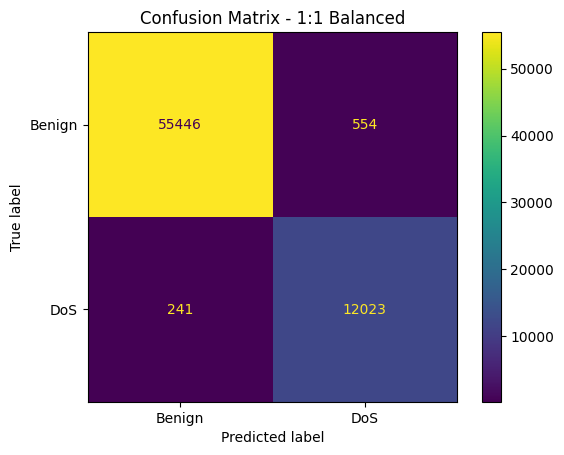

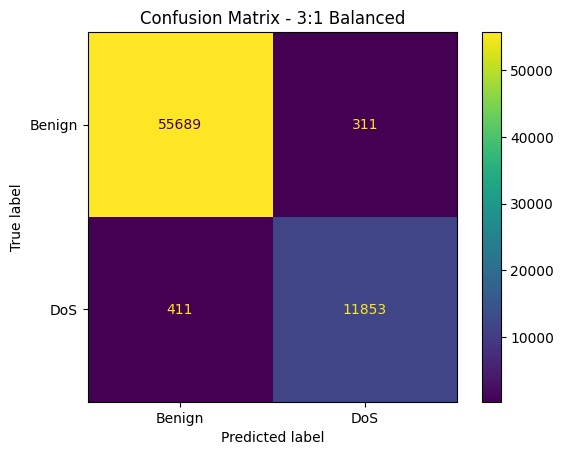

In [45]:
for name, result in results.items():
    cm = confusion_matrix(result["y_test"], result["y_pred"])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Benign", "DoS"]
    )

    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

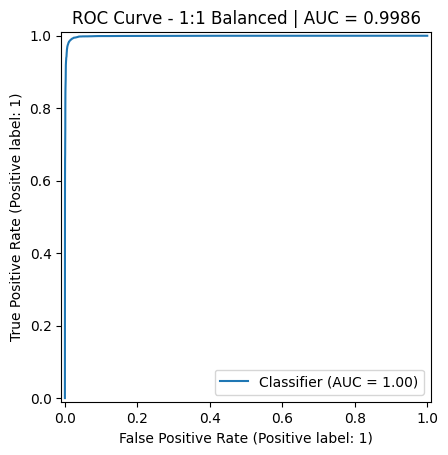

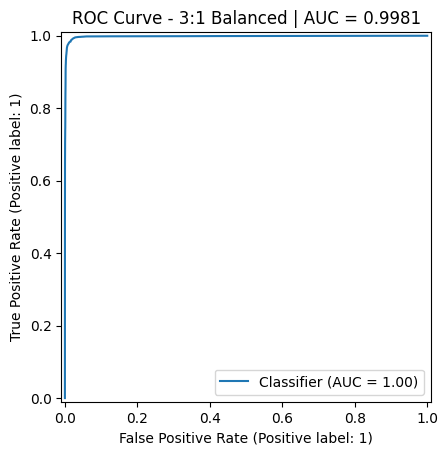

In [46]:
for name, result in results.items():
    auc_score = roc_auc_score(result["y_test"], result["y_prob"])

    RocCurveDisplay.from_predictions(
        result["y_test"],
        result["y_prob"]
    )

    plt.title(f"ROC Curve - {name} | AUC = {auc_score:.4f}")
    plt.show()

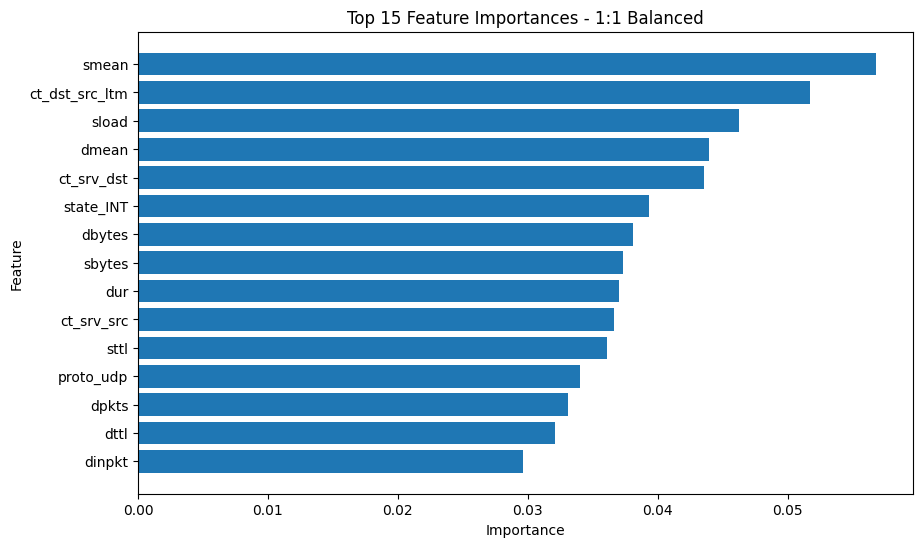

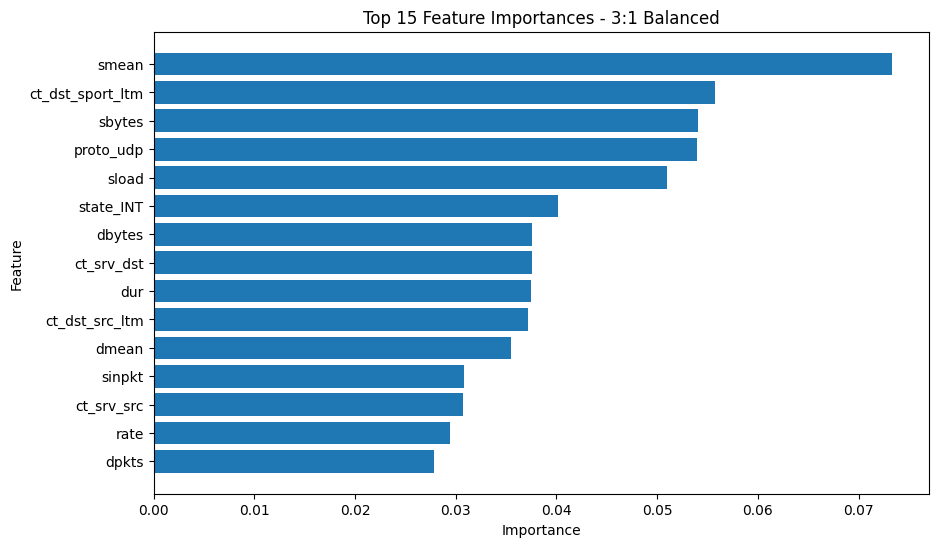

In [47]:
for name, result in results.items():
    model = result["model"]
    feature_names = result["X_train"].columns

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model.feature_importances_
    }).sort_values(by="Importance", ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    plt.barh(importance_df["Feature"], importance_df["Importance"])
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(f"Top 15 Feature Importances - {name}")
    plt.gca().invert_yaxis()
    plt.show()